In [9]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import numpy as np
import pandas as pd
import librosa
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt
import parselmouth
from parselmouth.praat import call

In [ ]:
sample_rate = 16000
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
times = 4
audio_files_meta = "metadata.csv"

In [3]:
df = pd.read_csv(audio_files_meta)
augmented_df = pd.read_csv(augmented_meta)

In [11]:
def extract_features(file_path):

    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)

    mfcc = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=13)
    mfcc_features = np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])

    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_features = delta_mfcc.mean(axis=1)

    chroma = librosa.feature.chroma_stft(
        S=np.abs(librosa.stft(y)), sr=sample_rate
    )
    chroma_features = chroma.mean(axis=1)

    rms = librosa.feature.rms(y=y)
    rms_features = np.array([rms.mean(), rms.std()])

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
    centroid_features = np.array([spectral_centroid.mean(), spectral_centroid.std()])

 
    f0, _, _ = librosa.pyin(y, fmin=50, fmax=400)
    f0_clean = f0[~np.isnan(f0)]
    if len(f0_clean) > 0:
        f0_features = np.array([
            f0_clean.mean(),
            f0_clean.std(),
            f0_clean.max() - f0_clean.min()  # range
        ])
    else:
        f0_features = np.zeros(3)  # fallback for unvoiced audio


    snd = parselmouth.Sound(file_path)
    harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr_values = harmonicity.values[harmonicity.values != -200] 
    hnr_mean = hnr_values.mean() if len(hnr_values) > 0 else 0.0

    features = np.hstack([
        mfcc_features,        # 26
        delta_mfcc_features,  # 13
        chroma_features,      # 12
        rms_features,         # 2
        centroid_features,    # 2
        f0_features,          # 3
        [hnr_mean]            # 1
    ])

    return features 

In [12]:
X, y_emotion_raw, y_intensity_raw, y_gender_raw = [], [], [], []

for _, row in augmented_df.iterrows():
    folder = out_dir if row["augmentation"] != "original" else in_dir
    if "wav" in row["file_name"]:
      path   = os.path.join(folder, row["file_name"])
    else:
      path   = os.path.join(folder, row["file_name"]+".wav")

    X.append(extract_features(path))
    y_emotion_raw.append(row["emotion"])
    y_intensity_raw.append(row["intensity"])
    y_gender_raw.append(row["gender"])

X = np.array(X)
y_emotion_raw = np.array(y_emotion_raw)
y_intensity_raw = np.array(y_intensity_raw)
y_gender_raw = np.array(y_gender_raw)

print(f"Feature matrix: {X.shape}")
print(f"Emotion labels: {np.unique(y_emotion_raw)}")
print(f"Intensity labels: {np.unique(y_intensity_raw)}")
print(f"Gender labels: {np.unique(y_gender_raw)}")

emotion_encoder = LabelEncoder()
intensity_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
y_intensity = intensity_encoder.fit_transform(y_intensity_raw)
y_gender = gender_encoder.fit_transform(y_gender_raw)

y = np.column_stack([y_emotion, y_intensity, y_gender])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_emotion
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(emotion_encoder, os.path.join("models","svm_emotion_encoder_improv.pkl"))
joblib.dump(intensity_encoder, os.path.join("models","svm_intensity_encoder_improv.pkl"))
joblib.dump(gender_encoder, os.path.join("models","svm_gender_encoder_improv.pkl"))
joblib.dump(scaler, os.path.join("models","svm_scaler_improv.gz"))

SystemError: CPUDispatcher(<function _viterbi at 0x1174349a0>) returned a result with an exception set

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best params: {'estimator__C': 10, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}

EMOTION CLASSIFICATION
              precision    recall  f1-score   support

       angry       0.61      0.65      0.63        96
        calm       0.57      0.61      0.59        96
     disgust       0.51      0.53      0.52        96
     fearful       0.49      0.41      0.44        96
       happy       0.52      0.53      0.53        96
         sad       0.39      0.39      0.39        96
   surprised       0.49      0.48      0.48        96

    accuracy                           0.51       672
   macro avg       0.51      0.51      0.51       672
weighted avg       0.51      0.51      0.51       672


INTENSITY CLASSIFICATION
              precision    recall  f1-score   support

      normal       0.75      0.78      0.77       356
      strong       0.74      0.71      0.73       316

    accuracy                         

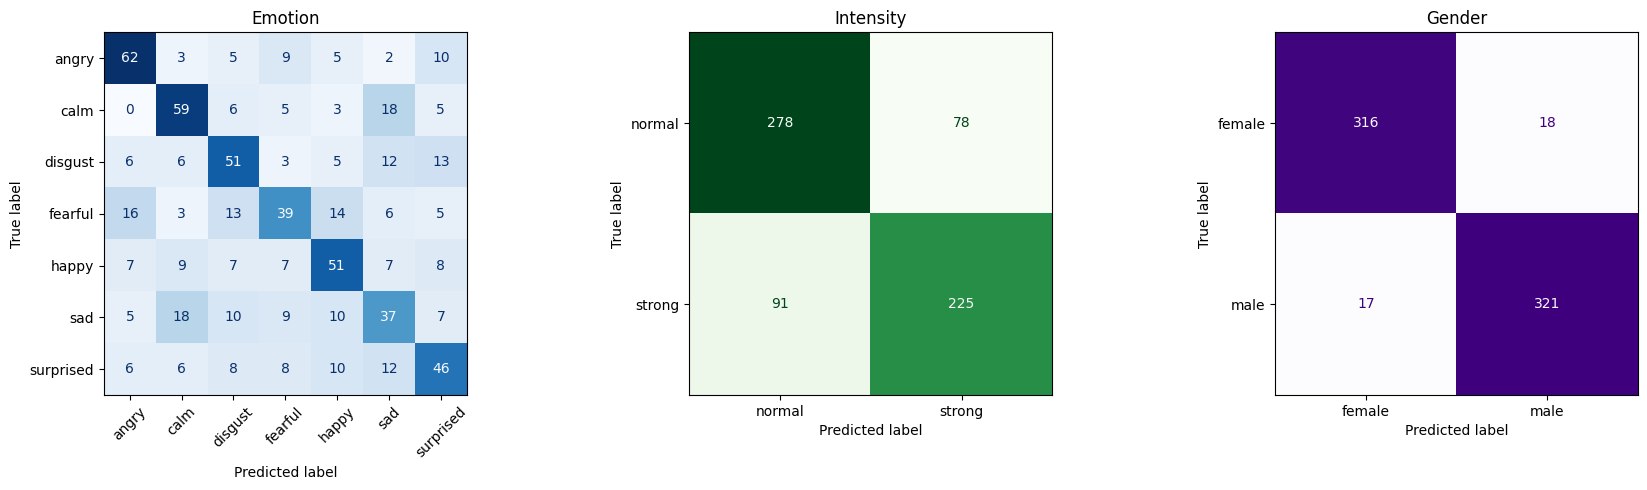

In [ ]:
param_grid = {
    "estimator__C":     [0.1, 1, 10],
    "estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__kernel": ['rbf'], 
}

base_svm = MultiOutputClassifier(
    SVC(class_weight="balanced", probability=True)
)

from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
multi_svm = GridSearchCV(
    base_svm,
    param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

multi_svm.fit(X_train, y_train)

joblib.dump(multi_svm, os.path.join("models","svm_multi_improv.pkl"))

print(f"\nBest params: {multi_svm.best_params_}")

y_pred = multi_svm.predict(X_test)

y_emotion_pred = y_pred[:, 0]
y_intensity_pred = y_pred[:, 1]
y_gender_pred = y_pred[:, 2]

y_emotion_test = y_test[:, 0]
y_intensity_test = y_test[:, 1]
y_gender_test = y_test[:, 2]

print("\n" + "=" * 60)
print("EMOTION CLASSIFICATION")
print("=" * 60)
print(classification_report(y_emotion_test, y_emotion_pred, target_names=emotion_encoder.classes_))

print("\n" + "=" * 60)
print("INTENSITY CLASSIFICATION")
print("=" * 60)
print(classification_report(y_intensity_test, y_intensity_pred, target_names=intensity_encoder.classes_))

print("\n" + "=" * 60)
print("GENDER CLASSIFICATION")
print("=" * 60)
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_encoder.classes_))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_emotion = confusion_matrix(y_emotion_test, y_emotion_pred)
ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion")

cm_intensity = confusion_matrix(y_intensity_test, y_intensity_pred)
ConfusionMatrixDisplay(cm_intensity, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity")

cm_gender = confusion_matrix(y_gender_test, y_gender_pred)
ConfusionMatrixDisplay(cm_gender, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender")

plt.tight_layout()
plt.show()

In [ ]:
scaler = joblib.load(os.path.join("models","svm_scaler_improv.gz"))
emotion_encoder = joblib.load(os.path.join("models","svm_emotion_encoder_improv.pkl"))
intensity_encoder = joblib.load(os.path.join("models","svm_intensity_encoder_improv.pkl"))
gender_encoder = joblib.load(os.path.join("models","svm_gender_encoder_improv.pkl"))

multi_svm = joblib.load(os.path.join("models","svm_multi_improv.pkl"))

In [ ]:
import datetime 

with open(f"test_logs/{datetime.datetime.now()}.log","w") as log:
    out = ""
    for (dirp,_,files) in os.walk("sk_test_audios"): 
        files.sort()
        for f in files:
            out += f"\nFile: {f}\n"
            feature = extract_features(os.path.join(dirp,f))
            feature_scaled = scaler.transform([feature])
            predictions = multi_svm.predict(feature_scaled)[0]

            predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
            predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
            predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

            out += f"\nPredicted Emotion: {predicted_emotion}\n"
            out += f"Predicted Intensity: {predicted_intensity}\n"
            out += f"Predicted Gender: {predicted_gender}\n"
    
    log.write(out)

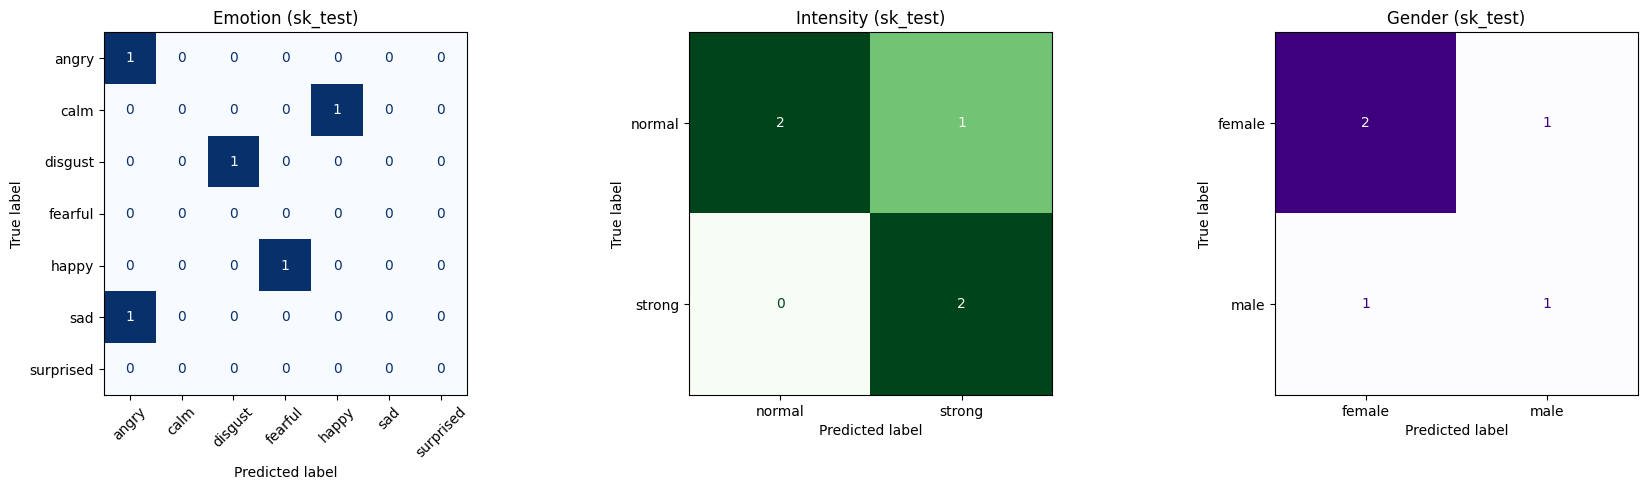


Emotion
              precision    recall  f1-score   support

       angry       0.50      1.00      0.67         1
        calm       0.00      0.00      0.00         1
     disgust       1.00      1.00      1.00         1
     fearful       0.00      0.00      0.00         0
       happy       0.00      0.00      0.00         1
         sad       0.00      0.00      0.00         1
   surprised       0.00      0.00      0.00         0

    accuracy                           0.40         5
   macro avg       0.21      0.29      0.24         5
weighted avg       0.30      0.40      0.33         5


Intensity
              precision    recall  f1-score   support

      normal       1.00      0.67      0.80         3
      strong       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5


Gender
              precision    recall  f1-score   su

In [23]:
sk_meta = pd.read_csv("sk_test_metadata.csv")

true_emotions, true_intensities, true_genders = [], [], []
pred_emotions, pred_intensities, pred_genders = [], [], []

for _, row in sk_meta.iterrows():
    file_path = os.path.join("sk_test_audios", f"audio{row['AudioID']}.wav")
    feature = extract_features(file_path)
    feature_scaled = scaler.transform([feature])
    preds = multi_svm.predict(feature_scaled)[0]

    true_emotions.append(row["Emotion"].lower())
    true_intensities.append(row["Intensity"].lower())
    true_genders.append(row["Gender"].lower())

    pred_emotions.append(emotion_encoder.inverse_transform([preds[0]])[0])
    pred_intensities.append(intensity_encoder.inverse_transform([preds[1]])[0])
    pred_genders.append(gender_encoder.inverse_transform([preds[2]])[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_e = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
ConfusionMatrixDisplay(cm_e, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion (sk_test)")

cm_i = confusion_matrix(true_intensities, pred_intensities, labels=intensity_encoder.classes_)
ConfusionMatrixDisplay(cm_i, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity (sk_test)")

cm_g = confusion_matrix(true_genders, pred_genders, labels=gender_encoder.classes_)
ConfusionMatrixDisplay(cm_g, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender (sk_test)")

plt.tight_layout()
plt.show()

print("\nEmotion")
print(classification_report(true_emotions, pred_emotions,
                             labels=emotion_encoder.classes_,
                             target_names=emotion_encoder.classes_,
                             zero_division=0))
print("\nIntensity")
print(classification_report(true_intensities, pred_intensities,
                             labels=intensity_encoder.classes_,
                             target_names=intensity_encoder.classes_,
                             zero_division=0))
print("\nGender")
print(classification_report(true_genders, pred_genders,
                             labels=gender_encoder.classes_,
                             target_names=gender_encoder.classes_,
                             zero_division=0))
